# *En este notebook calculamos las sobredensidades en el marco centrado en La Nube Mayor (LMC), filtrando datos de las estrellas y órbitas en un determinado rango de distancias: 15-21,21-24,24-35 kpc. Además se construye un quiver 2D para analizar la dirección de las velocidades y la detección de un posible Wake provocado por la Nube Menos (SMC)*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
# ASTROPY
import astropy.units as u
from astropy import constants as const
import astropy.coordinates as coord
from astropy.coordinates import SkyCoord
from astropy.coordinates import cartesian_to_spherical
# GALA
import gala.coordinates as gc
from gala.units import galactic
import gala.potential as galapot
# GALPY
import galpy.potential as galpy 
from galpy.orbit import Orbit
from galpy.potential import MovingObjectPotential,PlummerPotential,HernquistPotential
from galpy.potential import MiyamotoNagaiPotential,NFWPotential
# SCIPY
from scipy.interpolate import CubicSpline
from scipy import optimize
#Healpy
import healpy as hp
from healpy.newvisufunc import projview, newprojplot
#suavizar los mapas
fwhm2sigma = lambda fwhm: fwhm / np.sqrt(8*np.log(2))


## **Archivos a usar**

In [2]:
# datos de GAIA en LMC/SMC ya rotados
datos = pd.read_csv("datos_gaia_en_LMC.csv")
datos_SMC = pd.read_csv("datos_gaia_en_SMC.csv")
#orbita de la LMC en SMC
pas_LMC_en_SMC = pd.read_csv("pasada_LMC_en_SMC.csv")
fut_LMC_en_SMC = pd.read_csv("futura_LMC_en_SMC.csv")

#orbita de la SMC en LMC
pas_SMC_en_LMC = pd.read_csv("pasada_SMC_en_LMC.csv")
fut_SMC_en_LMC = pd.read_csv("futura_SMC_en_LMC.csv")

#orbita de la LMC en LMC
pas_LMC_en_LMC = pd.read_csv("pasada_LMC_en_LMC.csv")
fut_LMC_en_LMC = pd.read_csv("futura_LMC_en_LMC.csv")

#oirbita de la SMC en SMC
pas_SMC_en_SMC=pd.read_csv("pasada_SMC_en_SMC.csv")
fut_SMC_en_SMC=pd.read_csv("futura_SMC_en_SMC.csv")

#Wake y collective LMC 
Wake_sur_LMC=pd.read_csv("Wake_sur_LMC.csv")
Collective_LMC=pd.read_csv("Collective_LMC.csv")

#wake y collective SMC
Collective_SMC = pd.read_csv("Collective_SMC.csv")
Wake_norte_SMC = pd.read_csv("Wake_norte_SMC.csv")
Wake_sur_SMC   = pd.read_csv("Wake_sur_SMC.csv")

#GALAXIAS LMC
galaxias_LMC=pd.read_csv("galaxias_LMC.csv")
galaxias=pd.read_csv("galaxias.csv")
#comb_all_galaxies=pd.read_csv("/home/marz/Dropbox/PlanAB/SMC-wake-main/comb_all.csv")

In [3]:
datos_SMC.columns

Index(['source_id', 'ra', 'dec', 'l', 'b', 'R_sol_kpc', 'pmra*', 'pmdec*',
       'rad_vel*', 'x_icrs_kpc', 'y_icrs_kpc', 'z_icrs_kpc', 'x_LMC_new',
       'y_LMC_new', 'z_LMC_new', 'd_LMC_new', 'lat_LMC_new', 'long_LMC_new',
       'vx_icrs', 'vy_icrs', 'vz_icrs', 'vx_LMC_new', 'vy_LMC_new',
       'vz_LMC_new', 'x_SMC_new', 'y_SMC_new', 'z_SMC_new', 'd_SMC_new',
       'lat_SMC_new', 'long_SMC_new', 'vx_SMC_new', 'vy_SMC_new',
       'vz_SMC_new'],
      dtype='object')

In [4]:
datos.columns

Index(['source_id', 'ra', 'dec', 'l', 'b', 'R_sol_kpc', 'pmra*', 'pmdec*',
       'rad_vel*', 'x_icrs_kpc', 'y_icrs_kpc', 'z_icrs_kpc', 'x_LMC_new',
       'y_LMC_new', 'z_LMC_new', 'd_LMC_new', 'lat_LMC_new', 'long_LMC_new',
       'vx_icrs', 'vy_icrs', 'vz_icrs', 'vx_LMC_new', 'vy_LMC_new',
       'vz_LMC_new'],
      dtype='object')

# **Sobredensidades de los datos y órbitas para una banda en 15-21 kpc**

#### **Todos los datos, LMC frame**

### Función para los mapas de sobredensidad usando Mollviews para su visualización

#### Function adapted from: https://github.com/A-Vani/Healpy_Tutorial/blob/main/HEALPix%20Tutorial.ipynb

In [5]:
from astropy.coordinates import SkyCoord

def cat_to_hpx(lon, lat, nside, radec=False):   #radec=False: si vamos de cartesianas a esfericas galacticas
    """
    Convierte un catálogo a un mapa HEALPix de densidad de número, es decir,
    el número de estrellas por grado cuadrado de cielo.

    Parámetros
    ----------
    lon, lat : (arreglo, arreglo)
        Coordenadas de las fuentes en grados.
        Si radec=True, asume que la entrada está en el sistema ICRS,
        De lo contrario, asume que la entrada está en latitud y longitud galáctica.

    nside : int
        Número HEALPix nside del mapa de destino, define el número de píxeles.

    radec : bool
        Cambio entre Ra/Dec y l/b (galáctico) como sistema de coordenadas de entrada.

    Return
    ------
    hpx_map : arreglo
        Mapa HEALPix de los recuentos de número del catálogo en coordenadas galácticas
    """
    npix = hp.nside2npix(nside)

    if radec:
        eq = SkyCoord(lon, lat, unit='deg')
        l, b = eq.galactic.l.value, eq.galactic.b.value
    else:
        l, b = lon, lat

    # OJO ACA  

    theta = np.radians(90. - b)                 # latitud en radianes
    phi = np.radians(l)               # longitud en radianes        
    indices = hp.ang2pix(nside, theta, phi, lonlat=False)  


    indx, counts = np.unique(indices, return_counts=True)

    # llenar el mapa de cielo completo
    hpx_map = np.zeros(npix, dtype=int)
    hpx_map[indx] = counts

    return hpx_map


#### **Parámetros**

In [6]:
nside=256
lmax=3*nside-1

In [7]:
import astropy.coordinates as coord
#  mapa  kpc LMC
l_ang = coord.Angle(datos['long_LMC_new'].values*u.degree)
l_ang = l_ang.wrap_at(180*u.degree)
b_ang = coord.Angle(datos['lat_LMC_new'].values*u.degree)

c_gal = SkyCoord(l=l_ang, b=b_ang, frame='galactic')

l_new = c_gal.l.degree
b_new = c_gal.b.degree

l_new_rad=c_gal.l.radian
b_new_rad=c_gal.b.radian

mapa = cat_to_hpx(l_new,b_new, nside=nside, radec=False)

mapa_mean=mapa.mean()

#sobredensidad  LMC todos los datos 
sobre = (mapa-mapa_mean)/mapa_mean

#contraste 
delta = sobre/sobre.mean() - 1
#para la velocidad LMC, en radianes
ipix= hp.ang2pix(nside, np.pi/2-b_new_rad,l_new_rad)



#### **Calculo primero las órbitas**

In [8]:
#lat y long de pasadas de la SMC en LMC
lat_pas_SMC = pas_SMC_en_LMC['lat_LMC_new'].values
long_pas_SMC = pas_SMC_en_LMC['long_LMC_new'].values

#lat y long de futura de SMC en LMC
lat_fut_SMC= fut_SMC_en_LMC['lat_LMC_new'].values
long_fut_SMC= fut_SMC_en_LMC['long_LMC_new'].values

# lat long pasada de LMC en SMC
lat_pas_LMC = pas_LMC_en_SMC['lat_SMC_new'].values
long_pas_LMC = pas_LMC_en_SMC['long_SMC_new'].values

#lat long futura de LMC en SMC
lat_fut_LMC= fut_LMC_en_SMC['lat_SMC_new'].values
long_fut_LMC= fut_LMC_en_SMC['long_SMC_new'].values

# lat long pasada de LMC en SMC
lat_pas_LMC_ = pas_LMC_en_LMC['lat_LMC_new'].values
long_pas_LMC_ = pas_LMC_en_LMC['long_LMC_new'].values

#lat long futura de LMC en LMC
lat_fut_2LMC= fut_LMC_en_LMC['lat_LMC_new'].values
long_fut_2LMC= fut_LMC_en_LMC['long_LMC_new'].values

lat_pas_2LMC= pas_LMC_en_LMC['lat_LMC_new'].values
long_pas_2LMC= pas_LMC_en_LMC['long_LMC_new'].values


#####################################3 radianes

# PASAD DE LA SMC en eLMC rad
theta_pas_SMC = np.radians(lat_pas_SMC)
phi_pas_SMC   = np.radians(long_pas_SMC)

#futura de la SMC en LMC en rad
theta_fut_SMC = np.radians(90.0 - lat_fut_SMC)
phi_fut_SMC   = np.radians(long_fut_SMC)

#pasada de la 
theta_pas_2LMC = np.radians(90.0 - lat_pas_2LMC)
phi_pas_2LMC   = np.radians(long_pas_2LMC)
# PASAD DE LA LMC en SMC en rad
#theta_pas_LMC = np.radians(90.0 - lat_pas_LMC)mc
#phi_pas_LMC   = np.radians(long_pas_LMC)

#futura de la LMC en SMC en rad
#theta_fut_LMC = np.radians(90.0 - lat_fut_LMC)
#phi_fut_LMC   = np.radians(long_fut_LMC)


In [9]:

# hoy de la SMC usando la columna tiempo 
i0_SMC = np.argmin(np.abs(pas_SMC_en_LMC['tiempo'].values))  

lat0_SMC = lat_pas_SMC[i0_SMC]
lon0_SMC = long_pas_SMC[i0_SMC]

#en rad
theta0 = np.radians(90.0 - lat0_SMC)
phi0   = np.radians(lon0_SMC)


# LMC hoy en LMC-frame, siempre el origen 0,0
lon0_LMC, lat0_LMC = 0.0, 0.0

#en radianes 
theta0_LMC = np.radians(90.0 - lat0_LMC)
phi0_LMC   = np.radians(lon0_LMC)

### **Mollview sobredensidad para todas las estrellas. LMC frame. Rotado lon= 180º**

<Figure size 1200x700 with 0 Axes>

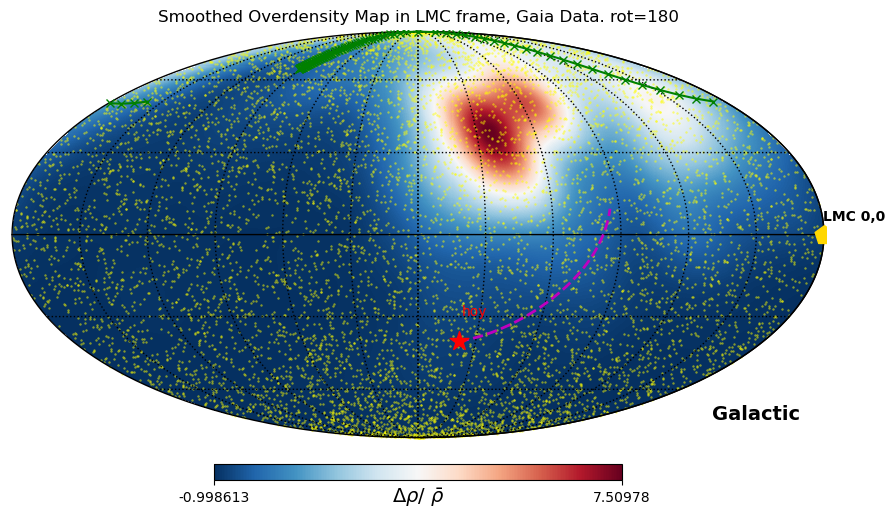

In [10]:

fig = plt.figure(figsize=(12, 7))

############ sobredensidad suavizada ###########
sobre_sm = hp.sphtfunc.smoothing(sobre, sigma=np.radians(fwhm2sigma(20))) # correspond to 20 deg


hp.mollview(sobre_sm,
             title='Smoothed Overdensity Map in LMC frame, Gaia Data. rot=180',
            coord='G', 
            rot=180, unit=r"$\Delta \rho /\ \bar{\rho}$", cmap='RdBu_r')  

hp.graticule()

# Posiciones "hoy" de SMC lonlat=True
hp.projscatter(lon0_SMC, lat0_SMC, lonlat=True, color='red', s=200, marker='*', zorder=12)
hp.projtext(lon0_SMC, lat0_SMC + 10, 'hoy', lonlat=True, fontsize=10, color='red', zorder=13)

# Posiciones "hoy" de LMC en grados lonlat=True
hp.projscatter(lon0_LMC, lat0_LMC, lonlat=True, color='gold', s=200, marker='p', zorder=12)
hp.projtext(lon0_LMC, lat0_LMC + 5, 'LMC 0,0', lonlat=True, fontsize=10,  color='k',fontweight="bold", zorder=13)

# orbitas pasada y futura con theta_pas, phi_pas en radianes,  SMC en LMC
hp.projplot(theta_pas_SMC, phi_pas_SMC, color='green',  marker='x',lw=1.5, label='Pasada SMC en LMC')
hp.projplot(theta_fut_SMC, phi_fut_SMC, 'm--', lw=2, label='SMC futura')

#estrellas GAIA
hp.projscatter(datos['long_LMC_new'],datos['lat_LMC_new'],c='yellow',marker='*',alpha=0.4,s=0.8, label='Datos Gaia')



<Figure size 1200x700 with 0 Axes>

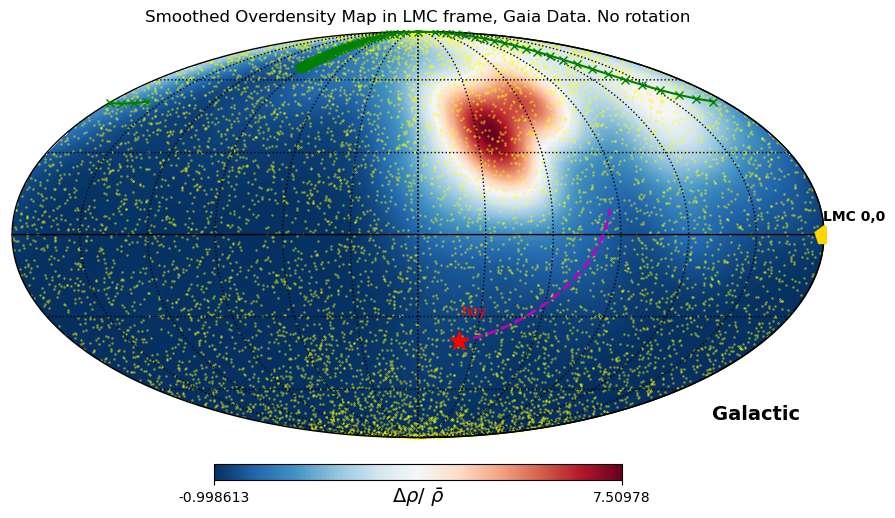

In [11]:

fig = plt.figure(figsize=(12, 7))

############ sobredensidad suavizada ###########
sobre_sm = hp.sphtfunc.smoothing(sobre, sigma=np.radians(fwhm2sigma(20))) # correspond to 20 deg


hp.mollview(sobre_sm,
             title='Smoothed Overdensity Map in LMC frame, Gaia Data. No rotation',
            coord='G', 
            rot=180, 
            unit=r"$\Delta \rho /\ \bar{\rho}$", cmap='RdBu_r')  

hp.graticule()

# Posiciones "hoy" de SMC lonlat=True
hp.projscatter(lon0_SMC, lat0_SMC, lonlat=True, color='red', s=200, marker='*', zorder=12)
hp.projtext(lon0_SMC, lat0_SMC + 10, 'hoy', lonlat=True, fontsize=10, color='red', zorder=13)

# Posiciones "hoy" de LMC en grados lonlat=True
hp.projscatter(lon0_LMC, lat0_LMC, lonlat=True, color='gold', s=200, marker='p', zorder=12)
hp.projtext(lon0_LMC, lat0_LMC + 5, 'LMC 0,0', lonlat=True, fontsize=10,  color='k',fontweight="bold", zorder=13)

# orbitas pasada y futura con theta_pas, phi_pas en radianes,  SMC en LMC
hp.projplot(theta_pas_SMC, phi_pas_SMC, color='green',  marker='x',lw=1.5, label='Pasada SMC en LMC')
hp.projplot(theta_fut_SMC, phi_fut_SMC, 'm--', lw=2, label='SMC futura')

#estrellas GAIA
hp.projscatter(datos['long_LMC_new'],datos['lat_LMC_new'],c='yellow',marker='*',alpha=0.4,s=0.8, label='Datos Gaia')



## **Sobredensidad para una banda entre 15-21 kpc, LMC frame**

#### **Filtro por distancia datos y órbitas**

In [12]:
datos1521 = datos[(datos["d_LMC_new"] >= 15) & (datos["d_LMC_new"] < 21)]

#orbita pasada de la SMC en LMC
pas_SMC_en_LMC1521 = pas_SMC_en_LMC[(pas_SMC_en_LMC["d_LMC_new"] >= 15) & (pas_SMC_en_LMC["d_LMC_new"] < 21)]
#orbi futura de la SMC en LMC
fut_SMC_en_LMC1521 = fut_SMC_en_LMC[(fut_SMC_en_LMC["d_LMC_new"] >= 15) & (fut_SMC_en_LMC["d_LMC_new"] < 21)]

In [13]:
datos1521

,source_id,ra,dec,l,b,R_sol_kpc,pmra*,pmdec*,rad_vel*,x_icrs_kpc,...,z_LMC_new,d_LMC_new,lat_LMC_new,long_LMC_new,vx_icrs,vy_icrs,vz_icrs,vx_LMC_new,vy_LMC_new,vz_LMC_new
66,5.277606e+18,122.181710,-62.715343,276.232487,-15.679627,46.891488,0.295528,-0.012943,-15.442104,-11.448689,...,6.260857,15.024745,24.626610,15.545666,-50.467352,-43.143426,12.405143,-295.746348,57.780292,15.751674
67,5.277612e+18,122.265374,-62.617039,276.163012,-15.597997,53.794010,-0.024545,-0.026484,-30.257597,-13.208192,...,0.471841,16.459979,1.642664,5.919520,15.923290,-13.497224,23.761009,-348.927550,7.250403,21.587797
69,5.277750e+18,124.230140,-62.619851,276.636181,-14.818252,42.451812,0.233959,-0.137434,-34.023989,-10.982190,...,10.098440,16.317584,38.233557,25.062464,-16.310115,-59.726713,17.493044,-333.837610,61.706577,16.869303
70,5.277786e+18,125.154777,-62.271298,276.559099,-14.271567,55.062674,-0.020391,0.005370,-29.572417,-14.751590,...,-0.343300,18.056233,-1.089420,6.998874,11.559913,-7.170869,26.828498,-343.021015,2.793698,25.292114
73,5.277254e+18,123.422599,-63.828701,277.524380,-15.745360,36.359933,0.397626,0.003368,-10.741872,-8.833218,...,14.825521,18.414939,53.618093,41.845226,-54.879642,-41.269865,9.896614,-290.723814,57.525574,13.756551
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8353,5.302499e+18,130.229536,-59.879657,275.942279,-10.899703,36.805125,-0.325799,-0.342796,-58.454711,-11.928532,...,15.947234,20.937585,49.610392,34.429419,95.754803,-25.179090,20.548615,-427.183995,-9.022753,10.143623
8381,4.624980e+18,73.682063,-76.637276,289.017516,-32.950589,67.443812,-0.192534,0.047372,113.287758,4.379513,...,-19.220146,19.265263,-86.078021,100.315503,70.572945,21.974622,-106.720268,-374.349001,-44.746961,-112.278644
8394,5.242509e+18,148.430508,-71.098302,289.471978,-13.032832,39.677563,-0.060431,-0.251772,42.418292,-10.951143,...,9.917255,19.285026,30.947097,59.601068,32.414820,-6.577126,-55.471611,-353.722979,-4.883911,-58.583448
8407,4.612065e+18,11.932089,-88.463394,302.960266,-28.664654,53.133678,-0.192863,-0.035570,47.905559,1.394027,...,-7.014843,17.952903,-23.000293,103.042330,2.537954,-49.114491,-48.128580,-341.003221,45.297463,-49.864956


In [14]:
# PASAD DE LA SMC en LMC rad
long_pas_wrapped = coord.Angle(pas_SMC_en_LMC1521['long_LMC_new'].values*u.degree).wrap_at(180*u.degree)
theta1521_pas_SMC = np.radians(90.0 - pas_SMC_en_LMC1521['lat_LMC_new'])
phi1521_pas_SMC = np.radians(long_pas_wrapped)

# futura de la SMC en LMC en rad
long_fut_wrapped = coord.Angle(fut_SMC_en_LMC1521['long_LMC_new'].values*u.degree).wrap_at(180*u.degree).value
theta1521_fut_SMC = np.radians(90.0 - fut_SMC_en_LMC1521['lat_LMC_new'])
phi1521_fut_SMC = np.radians(long_fut_wrapped)

In [15]:
# PASAD DE LA SMC en LMC rad
theta1521_pas_SMC = np.radians(90.0 - pas_SMC_en_LMC1521['lat_LMC_new'])
phi1521_pas_SMC = np.radians(pas_SMC_en_LMC1521['long_LMC_new'])

# futura de la SMC en LMC en rad
#long_fut_wrapped = coord.Angle(fut_SMC_en_LMC1521['long_LMC_new'].values*u.degree).wrap_at(180*u.degree).value
theta1521_fut_SMC = np.radians(90.0 - fut_SMC_en_LMC1521['lat_LMC_new'])
phi1521_fut_SMC = np.radians(fut_SMC_en_LMC1521['long_LMC_new'])

In [16]:
#  mapa1521  kpc LMC
l_ang = coord.Angle(datos1521['long_LMC_new'].values*u.degree)
l_ang = l_ang.wrap_at(180*u.degree)
b_ang = coord.Angle(datos1521['lat_LMC_new'].values*u.degree)

c_gal = SkyCoord(l=l_ang, b=b_ang, frame='galactic')

l_new = c_gal.l.degree
b_new = c_gal.b.degree

l_new_rad=c_gal.l.radian
b_new_rad=c_gal.b.radian

mapa1521 = cat_to_hpx(l_new,b_new, nside=nside, radec=False)

mapa1521_mean=mapa1521.mean()

#sobredensidad  LMC todos los datos1521 
sobre1521 = (mapa1521-mapa1521_mean)/mapa1521_mean





### **Mollview sobredensidad para estrellas en una banda de 15-21 kpc. LMC frame. Rotado lon= 180º**

In [17]:
%matplotlib inline

<Figure size 1200x700 with 0 Axes>

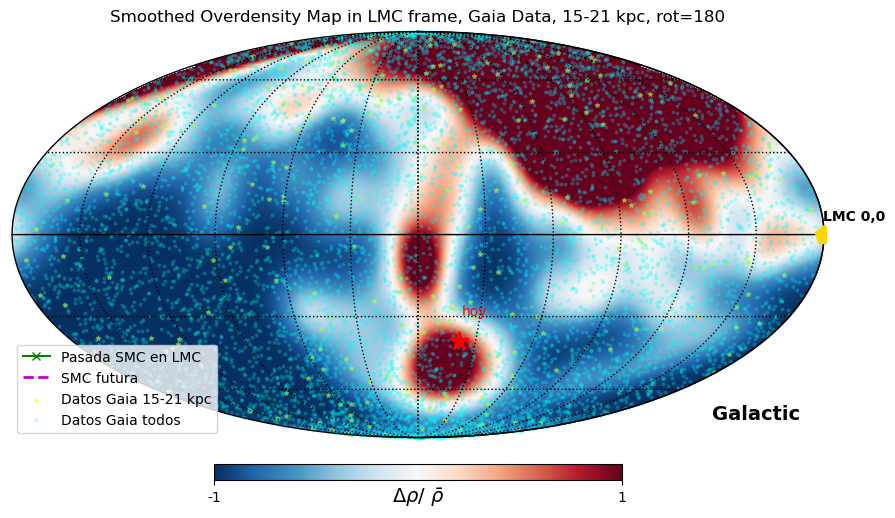

In [18]:

fig = plt.figure(figsize=(12, 7))

############ sobredensidad suavizada ###########
sobre1521_sm = hp.sphtfunc.smoothing(sobre1521, sigma=np.radians(fwhm2sigma(20))) # correspond to 20 deg


hp.mollview(sobre1521_sm,
            min=-1,max=1,
             title='Smoothed Overdensity Map in LMC frame, Gaia Data, 15-21 kpc, rot=180',
            coord='G', 
            rot=180, 
            unit=r"$\Delta \rho /\ \bar{\rho}$", cmap='RdBu_r')  

hp.graticule()

# Posiciones "hoy" de SMC lonlat=True
hp.projscatter(lon0_SMC, lat0_SMC, lonlat=True, color='red', s=200, marker='*', zorder=12)
hp.projtext(lon0_SMC, lat0_SMC + 10, 'hoy', lonlat=True, fontsize=10, color='red', zorder=13)

# Posiciones "hoy" de LMC en grados lonlat=True
hp.projscatter(lon0_LMC, lat0_LMC, lonlat=True, color='gold', s=200, marker='p', zorder=12)
hp.projtext(lon0_LMC, lat0_LMC + 5, 'LMC 0,0', lonlat=True, fontsize=10,  color='k',fontweight="bold", zorder=13)

#orbitas pasada y futura con theta_pas, phi_pas en radianes,  SMC en LMC
hp.projplot(theta1521_pas_SMC, phi1521_pas_SMC, color='green',  marker='x',lw=1.5, label='Pasada SMC en LMC')
hp.projplot(theta1521_fut_SMC, phi1521_fut_SMC, 'm--', lw=2, label='SMC futura')
#hp.projplot(pas_SMC_en_LMC1521['long_LMC_new'], pas_SMC_en_LMC1521['lat_LMC_new'])
#datos GAIA 1521
hp.projscatter(datos1521['long_LMC_new'],datos1521['lat_LMC_new'],c='yellow',marker='*',alpha=0.4,s=10, label='Datos Gaia 15-21 kpc')
#tod gaia 
hp.projscatter(datos['long_LMC_new'],datos['lat_LMC_new'],c='cyan',marker='.',alpha=0.2,s=14, label='Datos Gaia todos')

plt.legend(loc='lower left')
plt.show()

## **Sobredensidad para una banda de 21-24 kpc, LMC frame**

In [19]:
datos2124 = datos[(datos["d_LMC_new"] >= 21) & (datos["d_LMC_new"] <= 24)]

#orbita pasada de la SMC en LMC
pas_SMC_en_LMC2124 = pas_SMC_en_LMC[(pas_SMC_en_LMC["d_LMC_new"] >= 21) & (pas_SMC_en_LMC["d_LMC_new"] < 24)]
#orbi futura de la SMC en LMC
fut_SMC_en_LMC2124 = fut_SMC_en_LMC[(fut_SMC_en_LMC["d_LMC_new"] >= 21) & (fut_SMC_en_LMC["d_LMC_new"] < 24)]

In [20]:
# PASAD DE LA SMC en eLMC rad
theta2124_pas_SMC = np.radians(90.0 - pas_SMC_en_LMC2124['lat_LMC_new'])
phi2124_pas_SMC   = np.radians(pas_SMC_en_LMC2124['long_LMC_new'])

#futura de la SMC en LMC en rad
theta2124_fut_SMC = np.radians(90.0 - fut_SMC_en_LMC2124['lat_LMC_new'])
phi2124_fut_SMC   = np.radians(fut_SMC_en_LMC2124['long_LMC_new'])

In [21]:
# PASAD DE LA SMC en LMC rad
long_pas_wrapped = coord.Angle(pas_SMC_en_LMC2124['long_LMC_new'].values*u.degree).wrap_at(180*u.degree)
theta2124_pas_SMC = np.radians(90.0 - pas_SMC_en_LMC2124['lat_LMC_new'])
phi2124_pas_SMC = np.radians(long_pas_wrapped)

# futura de la SMC en LMC en rad
long_fut_wrapped = coord.Angle(fut_SMC_en_LMC2124['long_LMC_new'].values*u.degree).wrap_at(180*u.degree).value
theta2124_fut_SMC = np.radians(90.0 - fut_SMC_en_LMC2124['lat_LMC_new'])
phi2124_fut_SMC = np.radians(long_fut_wrapped)

In [22]:
#  mapa2124  kpc LMC
l_ang = coord.Angle(datos2124['long_LMC_new'].values*u.degree)
l_ang = l_ang.wrap_at(180*u.degree)
b_ang = coord.Angle(datos2124['lat_LMC_new'].values*u.degree)

c_gal = SkyCoord(l=l_ang, b=b_ang, frame='galactic')

l_new = c_gal.l.degree
b_new = c_gal.b.degree

l_new_rad=c_gal.l.radian
b_new_rad=c_gal.b.radian

mapa2124 = cat_to_hpx(l_new,b_new, nside=nside, radec=False)

mapa2124_mean=mapa2124.mean()

#sobredensidad  LMC todos los datos2124 
sobre2124 = (mapa2124-mapa2124_mean)/mapa2124_mean



<Figure size 1200x700 with 0 Axes>

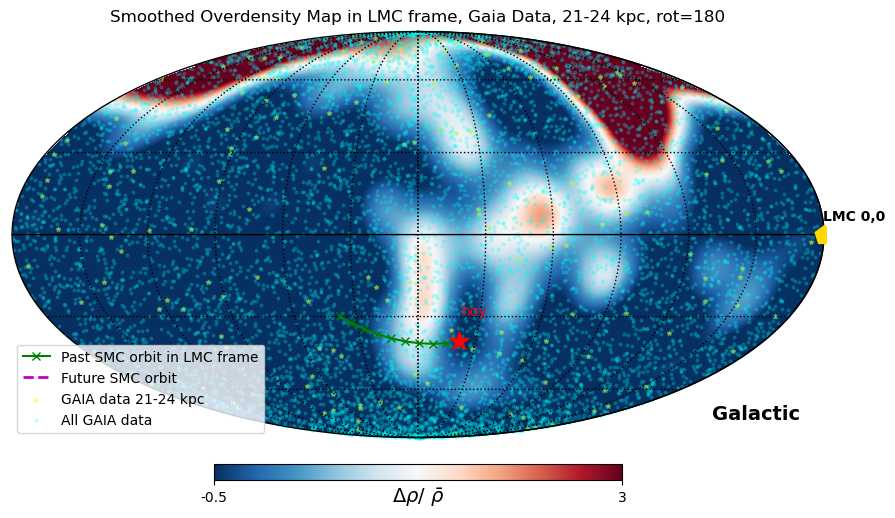

In [23]:

fig = plt.figure(figsize=(12, 7))

############ sobredensidad suavizada ###########
sobre2124_sm = hp.sphtfunc.smoothing(sobre2124, sigma=np.radians(fwhm2sigma(20))) # correspond to 20 deg


hp.mollview(sobre2124_sm,
            min=-0.5,max=3,
             title='Smoothed Overdensity Map in LMC frame, Gaia Data, 21-24 kpc, rot=180',
            coord='G', rot=180, unit=r"$\Delta \rho /\ \bar{\rho}$", cmap='RdBu_r')  

hp.graticule()

# Posiciones "hoy" de SMC lonlat=True
hp.projscatter(lon0_SMC, lat0_SMC, lonlat=True, color='red', s=200, marker='*', zorder=12)
hp.projtext(lon0_SMC, lat0_SMC + 10, 'hoy', lonlat=True, fontsize=10, color='red', zorder=13)

# Posiciones "hoy" de LMC en grados lonlat=True
hp.projscatter(lon0_LMC, lat0_LMC, lonlat=True, color='gold', s=200, marker='p', zorder=12)
hp.projtext(lon0_LMC, lat0_LMC + 5, 'LMC 0,0', lonlat=True, fontsize=10,  color='k',fontweight="bold", zorder=13)

#orbitas pasada y futura con theta_pas, phi_pas en radianes,  SMC en LMC
hp.projplot(theta2124_pas_SMC, phi2124_pas_SMC, color='green',  marker='x',lw=1.5, label='Past SMC orbit in LMC frame')
hp.projplot(theta2124_fut_SMC, phi2124_fut_SMC, 'm--', lw=2, label='Future SMC orbit')
#datos GAIA 2124
hp.projscatter(datos2124['long_LMC_new'],datos2124['lat_LMC_new'],c='yellow',marker='*',alpha=0.4,s=10, label='GAIA data 21-24 kpc')
#datos toda gaia
hp.projscatter(datos['long_LMC_new'],datos['lat_LMC_new'],c='cyan',marker='.',alpha=0.2,s=14, label='All GAIA data')

plt.legend(loc='lower left')
plt.savefig('wake_quiver-SMC-LMC-21-24kpc.png')
plt.show()

## **Sobredensidad para una banda de 24-30 kpc, LMC frame**

In [24]:
datos2430 = datos[(datos["d_LMC_new"] >= 24) & (datos["d_LMC_new"] <= 30)]

#orbita pasada de la SMC en LMC
pas_SMC_en_LMC2430 = pas_SMC_en_LMC[(pas_SMC_en_LMC["d_LMC_new"] >= 24) & (pas_SMC_en_LMC["d_LMC_new"] <= 30)]
#orbi futura de la SMC en LMC
fut_SMC_en_LMC2430 = fut_SMC_en_LMC[(fut_SMC_en_LMC["d_LMC_new"] >= 24) & (fut_SMC_en_LMC["d_LMC_new"] <= 30)]

In [25]:
# PASAD DE LA SMC en eLMC rad

theta2430_pas_SMC = np.radians(90.0 - pas_SMC_en_LMC2430['lat_LMC_new'])
phi2430_pas_SMC   = np.radians(pas_SMC_en_LMC2430['long_LMC_new'])

#futura de la SMC en LMC en rad
theta2430_fut_SMC = np.radians(90.0 - fut_SMC_en_LMC2430['lat_LMC_new'])
phi2430_fut_SMC   = np.radians(fut_SMC_en_LMC2430['long_LMC_new'])

In [26]:
from astropy.coordinates import Angle
#  mapa2430  kpc LMC
l_ang = coord.Angle(datos2430['long_LMC_new'].values*u.degree)
l_ang = l_ang.wrap_at(180*u.degree)
b_ang = coord.Angle(datos2430['lat_LMC_new'].values*u.degree)

c_gal = SkyCoord(l=l_ang, b=b_ang, frame='galactic')

l_new = c_gal.l.degree
b_new = c_gal.b.degree

l_new_rad=c_gal.l.radian
b_new_rad=c_gal.b.radian

mapa2430 = cat_to_hpx(l_new,b_new, nside=nside, radec=False)

mapa2430_mean=mapa2430.mean()

#sobredensidad  LMC todos los datos2430 
sobre2430 = (mapa2430-mapa2430_mean)/mapa2430_mean



<Figure size 1200x700 with 0 Axes>

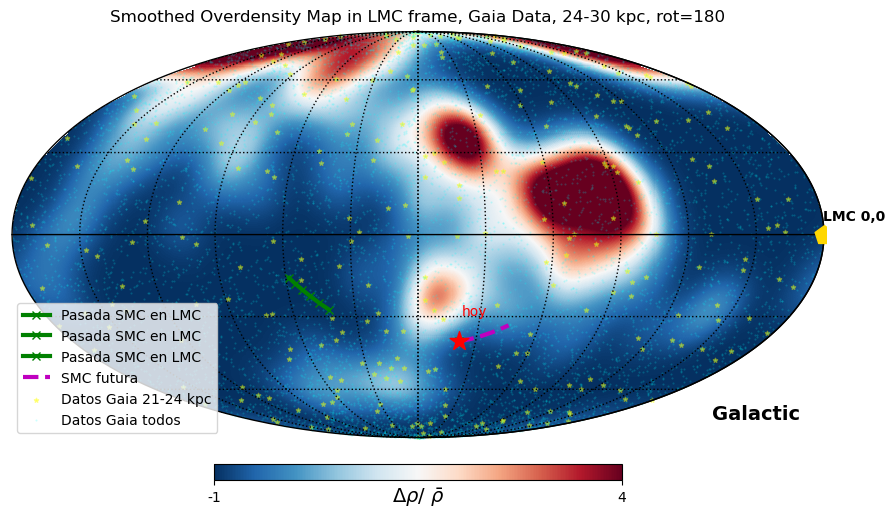

In [27]:

fig = plt.figure(figsize=(12, 7))

############ sobredensidad suavizada ###########
sobre2430_sm = hp.sphtfunc.smoothing(sobre2430, sigma=np.radians(fwhm2sigma(20))) # correspond to 20 deg


hp.mollview(sobre2430_sm,
            min=-1,max=4,
         title='Smoothed Overdensity Map in LMC frame, Gaia Data, 24-30 kpc, rot=180',
            coord='G', rot=180, unit=r"$\Delta \rho /\ \bar{\rho}$", cmap='RdBu_r')  

hp.graticule()

# Posiciones "hoy" de SMC lonlat=True
hp.projscatter(lon0_SMC, lat0_SMC, lonlat=True, color='red', s=200, marker='*', zorder=12)
hp.projtext(lon0_SMC, lat0_SMC + 10, 'hoy', lonlat=True, fontsize=10, color='red', zorder=13)

# Posiciones "hoy" de LMC en grados lonlat=True
hp.projscatter(lon0_LMC, lat0_LMC, lonlat=True, color='gold', s=200, marker='p', zorder=12)
hp.projtext(lon0_LMC, lat0_LMC + 5, 'LMC 0,0', lonlat=True, fontsize=10,  color='k',fontweight="bold", zorder=13)

#orbitas pasada y futura con theta_pas, phi_pas en radianes,  SMC en LMC
hp.projplot(theta2430_pas_SMC, phi2430_pas_SMC, color='green',  marker='x',lw=3, label='Pasada SMC en LMC')
hp.projplot(theta2430_fut_SMC, phi2430_fut_SMC, 'm--', lw=3, label='SMC futura')
#datos GAIA 2430
hp.projscatter(datos2430['long_LMC_new'],datos2430['lat_LMC_new'],c='yellow',marker='*',alpha=0.4,s=10, label='Datos Gaia 21-24 kpc')
#toda gaina
hp.projscatter(datos['long_LMC_new'],datos['lat_LMC_new'],c='cyan',marker='.',alpha=0.2,s=1, label='Datos Gaia todos')


plt.legend(loc='lower left')
plt.show()

In [28]:
phi2124_pas_SMC.min(), phi2124_pas_SMC.max()

(<Angle -3.02612392 rad>, <Angle 3.12965298 rad>)

In [29]:
phi2430_pas_SMC.min(), phi2430_pas_SMC.max()

(2.7714140315688214, 4.162857247389944)

## **quiver 2D para velocidades**

#### *Dado que ya estoy en el sistema centrado en la SMC, solo necesitamos aplicar R2, la rotación por el ángulo theta alrededor del eje x que alinea el plano orbital con el plano xz*

### Ahora ya tenemos calculadas las órbitas de las Nubes actualizadas con el perfil NFW 

In [30]:
# calcular 

theta = np.arctan( pas_SMC_en_SMC['z_SMC_new'] / pas_SMC_en_SMC['y_SMC_new'] ).mean()

In [31]:
# pas_SMC_en_SMC['x_SMC_new'].values 
# #pas_SMC_en_SMC['y_SMC_new'].values
# pas_SMC_en_SMC['z_SMC_new'].values

pas_SMC_en_SMC['x_rot'] = pas_SMC_en_SMC['x_SMC_new'].values
pas_SMC_en_SMC['y_rot'] = pas_SMC_en_SMC['y_SMC_new'].values*np.cos(theta) + pas_SMC_en_SMC['z_SMC_new'].values*np.sin(theta)
pas_SMC_en_SMC['z_rot'] = -pas_SMC_en_SMC['y_SMC_new'].values*np.sin(theta) + pas_SMC_en_SMC['z_SMC_new'].values*np.cos(theta)

In [32]:
pas_SMC_en_SMC['x_rot'].min(), pas_SMC_en_SMC['x_rot'].max()

(-164.54456815430834, 7.885804902677248e-15)

#### Para las velocidades hago exactamente lo mismo:

In [33]:
# pas_SMC_en_SMC['vx_SMC_new'].values 
# #pas_SMC_en_SMC['vy_SMC_new'].values
# pas_SMC_en_SMC['vz_SMC_new'].values

pas_SMC_en_SMC['vx_rot'] = pas_SMC_en_SMC['vx_SMC_new'].values
pas_SMC_en_SMC['vy_rot'] =  np.cos(theta)*pas_SMC_en_SMC['vy_SMC_new'].values + np.sin(theta)*pas_SMC_en_SMC['vz_SMC_new'].values
pas_SMC_en_SMC['vz_rot'] = -np.sin(theta)*pas_SMC_en_SMC['vy_SMC_new'].values + np.cos(theta)*pas_SMC_en_SMC['vz_SMC_new'].values

### Aplico la misma lógica para el Wake Sur y la Collective, usando el mismo ángulo theta. 

In [34]:
# posociones para el Wake sur SMC ##########################################

# Wake_sur_SMC['x_SMC_new'].values 
# #Wake_sur_SMC['y_SMC_new'].values
# Wake_sur_SMC['z_SMC_new'].values

Wake_sur_SMC['x_rot'] = Wake_sur_SMC['x_SMC_new'].values
Wake_sur_SMC['y_rot'] = Wake_sur_SMC['y_SMC_new'].values*np.cos(theta) + Wake_sur_SMC['z_SMC_new'].values*np.sin(theta)
Wake_sur_SMC['z_rot'] = -Wake_sur_SMC['y_SMC_new'].values*np.sin(theta) + Wake_sur_SMC['z_SMC_new'].values*np.cos(theta)

############################## velocidades para la wake SMC ###############################

# Wake_sur_SMC['vx_SMC_new'].values 
# #Wake_sur_SMC['vy_SMC_new'].values
# Wake_sur_SMC['vz_SMC_new'].values

Wake_sur_SMC['vx_rot'] = Wake_sur_SMC['vx_SMC_new'].values
Wake_sur_SMC['vy_rot'] =  np.cos(theta)*Wake_sur_SMC['vy_SMC_new'].values + np.sin(theta)*Wake_sur_SMC['vz_SMC_new'].values
Wake_sur_SMC['vz_rot'] = -np.sin(theta)*Wake_sur_SMC['vy_SMC_new'].values + np.cos(theta)*Wake_sur_SMC['vz_SMC_new'].values



Wake_sur_SMC.to_csv("Wake_sur_SMC_rotated.csv", index=False)

In [35]:
# y para la collective SMC ##########################################

# Collective['x_SMC_new'].values 
# #Collective['y_SMC_new'].values
# Collective['z_SMC_new'].values


Collective_SMC['x_rot'] = Collective_SMC['x_SMC_new'].values
Collective_SMC['y_rot'] =  np.cos(theta)*Collective_SMC['y_SMC_new'].values + np.sin(theta)*Collective_SMC['z_SMC_new'].values
Collective_SMC['z_rot'] = -np.sin(theta)*Collective_SMC['y_SMC_new'].values + np.cos(theta)*Collective_SMC['z_SMC_new'].values

# velocidades para la collective SMC ###############################
# Collective['vx_SMC_new'].values 
# #Collective['vy_SMC_new'].values
# Collective['vz_SMC_new'].values


Collective_SMC['vx_rot'] = Collective_SMC['vx_SMC_new'].values
Collective_SMC['vy_rot'] =  np.cos(theta)*Collective_SMC['vy_SMC_new'].values + np.sin(theta)*Collective_SMC['vz_SMC_new'].values
Collective_SMC['vz_rot'] = -np.sin(theta)*Collective_SMC['vy_SMC_new'].values + np.cos(theta)*Collective_SMC['vz_SMC_new'].values

Collective_SMC.to_csv("Collective_SMC_rotated.csv", index=False)

In [36]:
#UNiendo Wake_sur con Collective SMC

WAKE_COL = pd.concat([Wake_sur_SMC, Collective_SMC], ignore_index=True)

WAKE_COL

,source_id,ra,dec,l,b,R_sol_kpc,pmra*,pmdec*,rad_vel*,x_icrs_kpc,...,vz_icrs_SMC,vx_SMC_new,vy_SMC_new,vz_SMC_new,x_rot,y_rot,z_rot,vx_rot,vy_rot,vz_rot
0,5.912435e+18,262.780185,-60.279634,331.631105,-14.153433,45.866011,-0.125037,-0.503515,-68.222398,-2.857738,...,4.972718,-552.035088,-477.339910,-439.607316,28.951480,-26.633516,-3.892086,-552.035088,258.191468,-595.352961
1,5.912986e+18,263.115537,-59.095439,332.771305,-13.699324,72.886715,-0.132944,-0.437714,-98.319855,-4.487282,...,6.683565,-599.088929,-505.179603,-443.663586,46.076894,-6.159633,-8.264257,-599.088929,252.867396,-622.978241
2,4.194259e+18,293.203301,-10.154031,28.426114,-13.750024,40.142193,-0.042937,-0.135762,-50.212169,15.568100,...,-16.577782,-463.544613,-470.387897,-450.449849,32.831576,-51.152427,27.500891,-463.544613,270.717095,-592.353015
3,4.194775e+18,295.495165,-8.375545,31.095452,-15.012418,38.452541,0.003649,-0.183205,-50.641784,16.374791,...,-25.662552,-467.390219,-465.906126,-460.075287,30.540253,-52.222226,28.094413,-467.390219,281.281004,-591.285706
4,4.194619e+18,294.905959,-9.048722,30.205638,-14.782356,51.972131,-0.082394,-0.165903,-58.769770,21.614646,...,-31.122205,-460.377269,-487.479953,-464.714524,40.990483,-48.189577,35.696525,-460.377269,278.567935,-613.185289
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4578,5.779689e+17,132.641141,2.564640,225.066937,27.517182,46.132102,0.244747,0.156135,-69.040953,-31.218785,...,31.021359,-351.901958,-396.409711,-388.779037,-21.840916,-74.838972,-32.939920,-351.901958,236.802888,-502.209310
4579,5.796444e+17,138.349497,4.869524,225.993888,33.609840,40.559000,0.008783,0.127848,-10.863629,-30.196808,...,23.570362,-425.498130,-418.596909,-405.326406,-15.597447,-75.892411,-29.408938,-425.498130,245.133995,-528.604003
4580,3.839755e+18,143.489153,-0.902851,235.211601,34.908971,25.670000,-0.448087,-0.006526,1.562577,-20.629553,...,-0.818697,-480.874519,-412.434498,-436.701076,-6.813785,-69.148641,-18.548418,-480.874519,276.790239,-533.101499
4581,3.602397e+18,179.894649,-1.859852,277.568217,58.434763,48.858000,-0.204722,0.020153,109.433636,-48.832179,...,1.113535,-444.033269,-548.049468,-430.228835,15.755217,-78.108265,-39.467815,-444.033269,226.082549,-659.046092


Ya que todos estos valores están en el frame SMC, aplicamos solo R2. 

In [37]:
# algunos datos a recordar de la SMC 

#Datos de la SMC (data_SMC)
#vS,v_SMC,t1_SMC,t2_SMC,SMC_car=data_rotacion(data_SMC)
t1_SMC= -1.8599823646572682            # rad
t2_SMC= -0.12222517783162229           # rad
vx_SMC=-121.58884349 
vy_SMC=-408.66551583  
vz_SMC=-52.37421144                   # km / s
v_SMC_mod=429.5746835084161    

vel_SMC=[vx_SMC, vy_SMC, vz_SMC]


#Posición  icrs
dx_SMC = 18.084291633667192            # kpc
dy_SMC = 4.227648957870341             # kpc
dz_SMC = -59.99715327538697            # kpc

#posicion SMC-LCM 
dx_SMC_LMC = 15.368647609206464         #kpc
dy_SMC_LMC=-12.715321708945588
dz_SMC_LMC=-13.469786636364084

dist_SMC_LMC= np.sqrt(dx_SMC_LMC**2 + dy_SMC_LMC**2 + dz_SMC_LMC**2)  # kpc  
print(f'Distancia SMC-LMC: {dist_SMC_LMC} kpc')



Distancia SMC-LMC: 24.068857212737022 kpc


#### aplicamos directamente R2 a vx/vy/vz_SMC porque ya estas velocidades estan en el sistema centrado en la SMC (R1)

In [38]:
#MISMO theta de arriba

vx_SMC_rot = vx_SMC
vy_SMC_rot =  np.cos(theta)*vy_SMC + np.sin(theta)*vz_SMC
vz_SMC_rot = -np.sin(theta)*vy_SMC + np.cos(theta)*vz_SMC

In [39]:
stepx = 15
stepz = 15

x_mean, z_mean = [], []
vx_mean, vz_mean = [], []
cant = []

for ix in np.arange(-75, 50, stepx):
    for iz in np.arange(-30, 25, stepz):

        maskx = (WAKE_COL['x_rot'] > ix) & (WAKE_COL['x_rot'] < ix + stepx)
        maskz = (WAKE_COL['z_rot'] > iz) & (WAKE_COL['z_rot'] < iz + stepz)

        bin_df = WAKE_COL[maskx & maskz]
        if len(bin_df) == 0:
            continue

        x_mean.append(bin_df['x_rot'].mean())
        z_mean.append(bin_df['z_rot'].mean())

        # frame comóvil con la SMC
        vx_mean.append(bin_df['vx_rot'].mean() - vel_SMC[0])
        vz_mean.append(bin_df['vz_rot'].mean()) 

        cant.append(len(bin_df))

campoxz = pd.DataFrame({
    'x_rot':  x_mean,
    'z_rot':  z_mean,
    'vx_rot': vx_mean,
    'vz_rot': vz_mean,
    'cant':   cant
}).reset_index(drop=True)

campoxz.to_csv("campoxz_SMC_rotated.csv", index=False)


### **quiver 2D**

In [40]:
import k3d
import kde
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D
from matplotlib.path import Path
from matplotlib.legend_handler import HandlerTuple
from scipy import stats
import seaborn as sns

densidad media, max = 0.00015411885096687568 0.0003648150899651621
/tmp/ipykernel_27277/1655249066.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



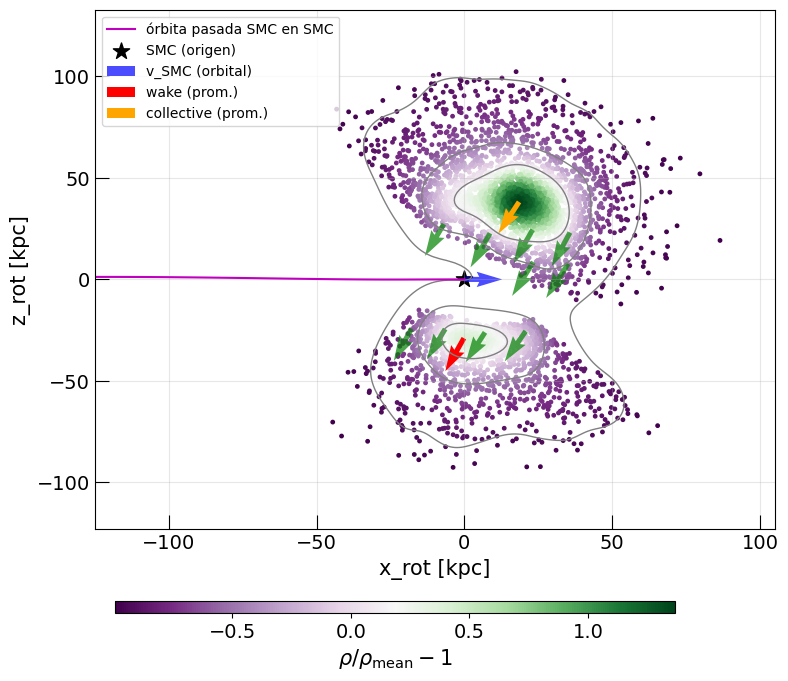

In [41]:
%matplotlib inline
fig, axs = plt.subplots(figsize=(8, 6))

#  PARTICULAS cerca del plano orbital y ~0
mask_plane = np.abs(WAKE_COL['y_rot']) < 100  

x = np.ravel(WAKE_COL[mask_plane]['x_rot'])
z = np.ravel(WAKE_COL[mask_plane]['z_rot'])

# kde de densidad en el plano x-z
density = gaussian_kde(np.vstack([x, z]))
density_values = density(np.vstack([x, z]))
mean_densidad_tot = density_values.mean()
maximo_densidad_tot = density_values.max()
print("densidad media, max =", mean_densidad_tot, maximo_densidad_tot)

# df reducido con sobredensidad normalizada
reducido = WAKE_COL[mask_plane][['x_rot', 'y_rot', 'z_rot']].copy()
reducido['densidad_norm'] = density_values / mean_densidad_tot - 1

# escater color por sobredensidad 
sc = axs.scatter(
    reducido['x_rot'],
    reducido['z_rot'],
    c=reducido['densidad_norm'],
    cmap='PRGn',
    s=6
)


cbar_ax = fig.add_axes([0.15, -0.03, 0.7, 0.02])
cb = fig.colorbar(sc, cax=cbar_ax, orientation='horizontal')
cb.set_label(label=r'$\rho/\rho_{\rm mean}-1$', size=15)
cb.ax.tick_params(labelsize=14)

# para los contornos de densidad
sns.kdeplot(
    x=reducido['x_rot'],
    y=reducido['z_rot'],
    levels=4,
    color="gray",
    linewidths=1,
    ax=axs
)

# aqui hago ña rottia pasada de la SMC en el frame de la SMC MISMO plano rotital 
#  rotita a x_rot, z_rot ya rotadas con R2
axs.plot(
    pas_SMC_en_SMC['x_rot'],
    pas_SMC_en_SMC['z_rot'],
    c='m',
    label='órbita pasada SMC en SMC'
)


# origen de la SMC
# SMC en el origen y velocidad relativa SMC-LMC 
axs.scatter(0, 0, marker='*', s=150, c='k', label='SMC (origen)')
axs.quiver(
    0, 0, -vel_SMC[0],0,  
    color='blue',
    alpha=0.7,
    label='v_SMC (orbital)'
)

# velocidades promedios (binned) del halo 
mask_x = campoxz['cant'] > 25  # solo bins con suficiente número de partículas
axs.quiver(
    campoxz[mask_x]['x_rot'],
    campoxz[mask_x]['z_rot'],
    campoxz[mask_x]['vx_rot'],   # ya fueron restadas cuando hice campoxz
    campoxz[mask_x]['vz_rot'],
    color='g',
    alpha=0.7
)

# para el wake y la collective 
ppw = reducido[reducido['x_rot'] < 0]  # wake: lado izquierdo
mwake = ppw['densidad_norm']
ppc = reducido[reducido['x_rot'] > 0]  # collective: lado derecho
mcol = ppc['densidad_norm']

xp_w = ppw.iloc[np.argmax(mwake)]['x_rot']
yp_w=ppw.iloc[np.argmax(mwake)]['y_rot']
zp_w = ppw.iloc[np.argmax(mwake)]['z_rot']
xp_c = ppc.iloc[np.argmax(mcol)]['x_rot']
yp_c=ppc.iloc[np.argmax(mcol)]['y_rot']
zp_c = ppc.iloc[np.argmax(mcol)]['z_rot']

# mask cerca del plano para cada df
mask_w = np.abs(Wake_sur_SMC['y_rot']) < 100
mask_c = np.abs(Collective_SMC['y_rot']) < 100

# wake: vector promedio en el wake
axs.quiver(
    xp_w, zp_w,
    Wake_sur_SMC[mask_w]['vx_rot'].mean()-vel_SMC[0], 
    Wake_sur_SMC[mask_w]['vz_rot'].mean(),
    color='r',
    label='wake (prom.)'
)

# collective vedctor promedio en la collective
axs.quiver(
    xp_c, zp_c,
    Collective_SMC[mask_c]['vx_rot'].mean()-vel_SMC[0],
    Collective_SMC[mask_c]['vz_rot'].mean(),
    color='orange',
    label='collective (prom.)'
)


axs.grid(alpha=0.3)
axs.set_xlim(-125, 105)
axs.set_xlabel('x_rot [kpc]', fontsize=15)
axs.set_ylabel('z_rot [kpc]', fontsize=15)
axs.tick_params(axis='both', labelsize=14, direction='in', which='both', length=10)

axs.legend()

plt.tight_layout()
#plt.savefig('wake_collective_overdensity_orbital_frame_xz.pdf', bbox_inches='tight')
plt.show()


In [42]:
stepx = 15
stepz = 15

x_mean, z_mean = [], []
vx_mean, vz_mean = [], []
cant = []

for ix in np.arange(-75, 50, stepx):
    for iz in np.arange(-30, 25, stepz):

        maskx = (WAKE_COL['x_rot'] > ix) & (WAKE_COL['x_rot'] < ix + stepx)
        maskz = (WAKE_COL['z_rot'] > iz) & (WAKE_COL['z_rot'] < iz + stepz)

        bin_df = WAKE_COL[maskx & maskz]
        if len(bin_df) == 0:
            continue

        x_mean.append(bin_df['x_rot'].mean())
        z_mean.append(bin_df['z_rot'].mean())

        # frame comóvil con la SMC
        vx_mean.append(bin_df['vx_rot'].mean())
        vz_mean.append(bin_df['vz_rot'].mean()) 

        cant.append(len(bin_df))

axs.quiver(
    campoxz['x_rot'],
    campoxz['z_rot'],
    campoxz['vx_rot'],
    campoxz['vz_rot'],
    color='g',
    alpha=0.7
)


#campoxz.to_csv("campoxz_SMC_rotated.csv", index=False)


densidad media, max = 0.00015411885096687568 0.0003648150899651621
/tmp/ipykernel_27277/534530983.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



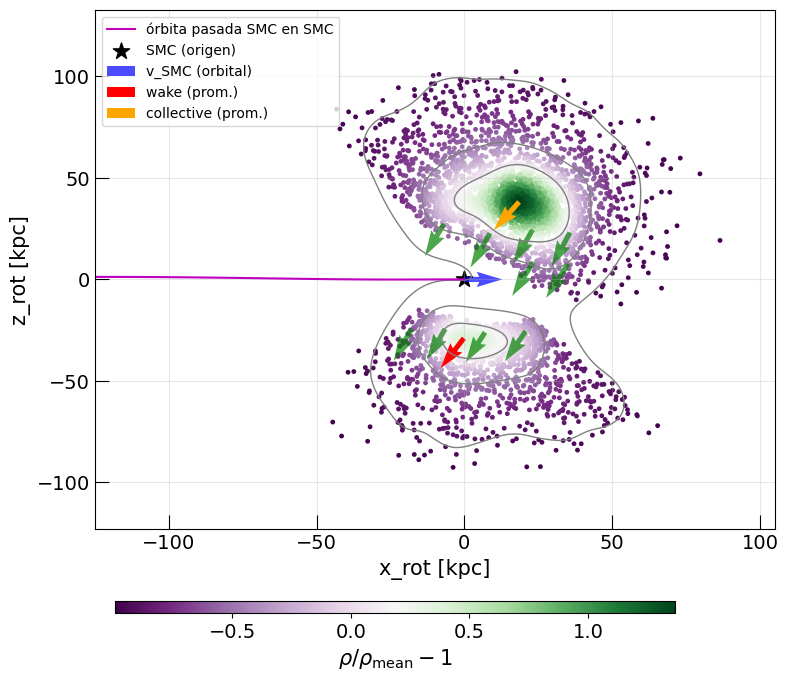

In [43]:
%matplotlib inline
fig, axs = plt.subplots(figsize=(8, 6))

#  PARTICULAS cerca del plano orbital y ~0
mask_plane = np.abs(WAKE_COL['y_rot']) < 100  

x = np.ravel(WAKE_COL[mask_plane]['x_rot'])
z = np.ravel(WAKE_COL[mask_plane]['z_rot'])

# kde de densidad en el plano x-z
density = gaussian_kde(np.vstack([x, z]))
density_values = density(np.vstack([x, z]))
mean_densidad_tot = density_values.mean()
maximo_densidad_tot = density_values.max()
print("densidad media, max =", mean_densidad_tot, maximo_densidad_tot)

# df reducido con sobredensidad normalizada
reducido = WAKE_COL[mask_plane][['x_rot', 'y_rot', 'z_rot']].copy()
reducido['densidad_norm'] = density_values / mean_densidad_tot - 1

# escater color por sobredensidad 
sc = axs.scatter(
    reducido['x_rot'],
    reducido['z_rot'],
    c=reducido['densidad_norm'],
    cmap='PRGn',
    s=6
)


cbar_ax = fig.add_axes([0.15, -0.03, 0.7, 0.02])
cb = fig.colorbar(sc, cax=cbar_ax, orientation='horizontal')
cb.set_label(label=r'$\rho/\rho_{\rm mean}-1$', size=15)
cb.ax.tick_params(labelsize=14)

# para los contornos de densidad
sns.kdeplot(
    x=reducido['x_rot'],
    y=reducido['z_rot'],
    levels=4,
    color="gray",
    linewidths=1,
    ax=axs
)

# aqui hago ña rottia pasada de la SMC en el frame de la SMC MISMO plano rotital 
#  rotita a x_rot, z_rot ya rotadas con R2
axs.plot(
    pas_SMC_en_SMC['x_rot'],
    pas_SMC_en_SMC['z_rot'],
    c='m',
    label='órbita pasada SMC en SMC'
)


# origen de la SMC
# SMC en el origen y velocidad relativa SMC-LMC 
axs.scatter(0, 0, marker='*', s=150, c='k', label='SMC (origen)')
axs.quiver(
    0, 0, -vel_SMC[0],0,  
    color='blue',
    alpha=0.7,
    label='v_SMC (orbital)'
)

# velocidades promedios (binned) del halo 
mask_x = campoxz['cant'] > 25  # solo bins con suficiente número de partículas
axs.quiver(
    campoxz[mask_x]['x_rot'],
    campoxz[mask_x]['z_rot'],
    campoxz[mask_x]['vx_rot'],   # ya fueron restadas cuando hice campoxz
    campoxz[mask_x]['vz_rot'],
    color='g',
    alpha=0.7
)

# para el wake y la collective 
ppw = reducido[reducido['x_rot'] < 0]  # wake: lado izquierdo
mwake = ppw['densidad_norm']
ppc = reducido[reducido['x_rot'] > 0]  # collective: lado derecho
mcol = ppc['densidad_norm']

xp_w = ppw.iloc[np.argmax(mwake)]['x_rot']
yp_w=ppw.iloc[np.argmax(mwake)]['y_rot']
zp_w = ppw.iloc[np.argmax(mwake)]['z_rot']
xp_c = ppc.iloc[np.argmax(mcol)]['x_rot']
yp_c=ppc.iloc[np.argmax(mcol)]['y_rot']
zp_c = ppc.iloc[np.argmax(mcol)]['z_rot']

# mask cerca del plano para cada df
mask_w = np.abs(Wake_sur_SMC['y_rot']) < 100
mask_c = np.abs(Collective_SMC['y_rot']) < 100

# wake: vector promedio en el wake
axs.quiver(
    xp_w, zp_w,
    Wake_sur_SMC[mask_w]['vx_rot'].mean(), 
    Wake_sur_SMC[mask_w]['vz_rot'].mean(),
    color='r',
    label='wake (prom.)'
)

# collective vedctor promedio en la collective
axs.quiver(
    xp_c, zp_c,
    Collective_SMC[mask_c]['vx_rot'].mean(),
    Collective_SMC[mask_c]['vz_rot'].mean(),
    color='orange',
    label='collective (prom.)'
)


axs.grid(alpha=0.3)
axs.set_xlim(-125, 105)
axs.set_xlabel('x_rot [kpc]', fontsize=15)
axs.set_ylabel('z_rot [kpc]', fontsize=15)
axs.tick_params(axis='both', labelsize=14, direction='in', which='both', length=10)

axs.legend()

plt.tight_layout()
#plt.savefig('wake_collective_overdensity_orbital_frame_xz.pdf', bbox_inches='tight')
plt.show()
